<a href="https://colab.research.google.com/github/hhayan/NLP/blob/main/NLP_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 필수 패키지 설치
!pip install -U bitsandbytes accelerate transformers datasets peft -qq
!apt-get update -qq
!apt-get install fonts-nanum -qq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.6/526.6 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 10.8 MB/s eta 0:00:00
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 121852 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [ ]:
# 초기 설정 및 라이브러리 설치
import os
import re
import time
from collections import Counter
from scipy.special import softmax
from peft import LoraConfig, get_peft_model, TaskType
from sklearn.utils.class_weight import compute_class_weight
from datasets import Dataset
from transformers import EarlyStoppingCallback
from sklearn.metrics import precision_recall_curve, auc, fbeta_score
import json
from google.colab import userdata, drive
from tqdm import tqdm
import pandas as pd
import numpy as np
import torch
import huggingface_hub
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score
)
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
fm._load_fontmanager(try_read_cache=False)

# ============================================
# 경로 및 모델 설정 (전역 변수)
# ============================================
BASE_PATH = '/content/drive/MyDrive/브라질 이커머스/NLP'
SAVE_PATH = f'{BASE_PATH}/processed'
RESULT_PATH = f'{SAVE_PATH}/results'
CHECKPOINT_PATH = f'{SAVE_PATH}/checkpoints'
MODEL_ID = "tabularisai/multilingual-sentiment-analysis"

# 데이터 로드
drive.mount('/content/drive')
reviews_df = pd.read_csv('/content/drive/MyDrive/브라질 이커머스/project_olist_ecommerce/project_dataset/olist_reviews_clean.csv')
reviews_df.info()
n_categories = reviews_df['product_category_name'].nunique()
print(f"카테고리 수: {n_categories}")

# 클래스 분포
class_dist = reviews_df['review_score'].value_counts().sort_index()
print(class_dist)
print(f"비율: {(class_dist / len(reviews_df) * 100).round(2)}")

# 불균형 체크
max_ratio = class_dist.max() / class_dist.min()
print(f"불균형 비율: {max_ratio:.2f}배")
if max_ratio > 3:
    print("클래스 불균형 → class_weight 필요")

# 리뷰별 길이 계산
review_lengths = reviews_df['review_comment_message'].str.len()
print(f"최대 길이: {review_lengths.max()}")

# 레이블 생성
reviews_df['sentiment'] = reviews_df['review_score'] - 1  # 1→0, 2→1, 3→2, 4→3, 5→4

print("레이블 매핑 확인")
mapping_check = reviews_df.groupby('review_score')['sentiment'].unique()
for score, sent in mapping_check.items():
    print(f"review_score {score} → sentiment {sent[0]}")

# Phase 1-2: Train/Val/Test 분할 (7:1.5:1.5)
train_df, temp_df = train_test_split(
    reviews_df,
    test_size=0.3,
    stratify=reviews_df['sentiment'],
    random_state=42
)

# Temp: Val(15%) / Test(15%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['sentiment'],
    random_state=42
)

print(f"Train: {len(train_df):,}개 ({len(train_df)/len(reviews_df)*100:.1f}%)")
print(f"Val:   {len(val_df):,}개 ({len(val_df)/len(reviews_df)*100:.1f}%)")
print(f"Test:  {len(test_df):,}개 ({len(test_df)/len(reviews_df)*100:.1f}%)")

# 클래스 분포 확인
print("Train 클래스 분포:")
print(train_df['sentiment'].value_counts().sort_index())

# 토큰 길이 확인
# Hugging Face 로그인
huggingface_hub.login(token=userdata.get('NLP_TOKEN'))
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

# 샘플 1000개로 토큰 길이 측정
sample_texts = reviews_df['review_comment_message'].sample(1000, random_state=42)
token_lengths = [len(tokenizer.encode(text, add_special_tokens=True)) for text in sample_texts]

print("토큰 길이 통계:")
print(f"평균: {sum(token_lengths)/len(token_lengths):.1f}")
print(f"95%: {sorted(token_lengths)[int(len(token_lengths)*0.95)]}")
print(f"99%: {sorted(token_lengths)[int(len(token_lengths)*0.99)]}")

# max_length 권장
max_length = sorted(token_lengths)[int(len(token_lengths)*0.95)]
if max_length <= 128:
    print("max_length: 128")
else:
    print(f"max_length: {max_length}")

# 데이터 저장
os.makedirs(SAVE_PATH, exist_ok=True)

train_df.to_csv(f'{SAVE_PATH}/train.csv', index=False)
val_df.to_csv(f'{SAVE_PATH}/val.csv', index=False)
test_df.to_csv(f'{SAVE_PATH}/test.csv', index=False)

Mounted at /content/drive
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33491 entries, 0 to 33490
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   review_score            33491 non-null  int64 
 1   review_comment_message  33491 non-null  object
 2   product_category_name   33491 non-null  object
dtypes: int64(1), object(2)
memory usage: 785.1+ KB
카테고리 수: 72
review_score
1     6800
2     1864
3     3099
4     4916
5    16812
Name: count, dtype: int64
비율: review_score
1    20.30
2     5.57
3     9.25
4    14.68
5    50.20
Name: count, dtype: float64
불균형 비율: 9.02배
클래스 불균형 → class_weight 필요
최대 길이: 208
레이블 매핑 확인
review_score 1 → sentiment 0
review_score 2 → sentiment 1
review_score 3 → sentiment 2
review_score 4 → sentiment 3
review_score 5 → sentiment 4
Train: 23,443개 (70.0%)
Val:   5,024개 (15.0%)
Test:  5,024개 (15.0%)
Train 클래스 분포:
sentiment
0     4760
1     1305
2     2169
3     3441
4    117

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/851 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

토큰 길이 통계:
평균: 22.7
95%: 54
99%: 63
max_length: 128


In [ ]:
# ============================================
# Phase 1.5: 베이스 모델 비교 (파인튜닝 전)
# ============================================
# 목적: LoRA 파인튜닝할 베이스 모델 선정

print("="*70)
print("🔍 베이스 모델 비교 (100 샘플)")
print("="*70)

# 샘플 데이터 로드
sample_df = pd.read_csv('/content/drive/MyDrive/브띴질 이커머스/NLP/processed/sentiment_samples_100.csv')
print(f"\n샘플 데이터: {len(sample_df)}개")
print(f"클래스 분포:\n{sample_df['review_score'].value_counts().sort_index()}")

# 비교 대상 모델
models_to_compare = {
    "tabularisai": "tabularisai/multilingual-sentiment-analysis",
    "modernBERT": "clapAI/modernBERT-base-multilingual-sentiment"
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
results = {}

# ============================================
# 각 모델 평가
# ============================================
for model_name, model_id in models_to_compare.items():
    print(f"\n{'='*70}")
    print(f"📊 {model_name} 평가 중...")
    print(f"   모델: {model_id}")
    print(f"{'='*70}")

    # 모델 & 토크나이저 로드
    tokenizer_temp = AutoTokenizer.from_pretrained(model_id)
    model_temp = AutoModelForSequenceClassification.from_pretrained(model_id)
    model_temp.to(device)
    model_temp.eval()

    # 파라미터 수 계산
    total_params = sum(p.numel() for p in model_temp.parameters())
    trainable_params = sum(p.numel() for p in model_temp.parameters() if p.requires_grad)

    print(f"총 파라미터:   {total_params:,}")
    print(f"학습 가능:     {trainable_params:,}")

    # 추론
    texts = sample_df['review_comment_message'].tolist()
    y_true_sample = sample_df['review_score'].values

    predictions = []
    probs = []

    # 추론 시간 측정
    start_time = time.time()

    with torch.no_grad():
        for text in texts:
            inputs = tokenizer_temp(
                text,
                return_tensors="pt",
                truncation=True,
                padding=True,
                max_length=128
            ).to(device)

            outputs = model_temp(**inputs)
            prob = torch.softmax(outputs.logits, dim=-1).cpu().numpy()[0]
            pred = torch.argmax(outputs.logits, dim=-1).cpu().numpy()[0]

            probs.append(prob)
            predictions.append(pred)

    inference_time = time.time() - start_time
    samples_per_sec = len(texts) / inference_time

    y_pred_sample = np.array(predictions)

    # 성능 계산
    weighted_f1 = f1_score(y_true_sample, y_pred_sample, average='weighted')
    macro_f1 = f1_score(y_true_sample, y_pred_sample, average='macro')
    accuracy = (y_true_sample == y_pred_sample).mean()
    recall_per_class = recall_score(y_true_sample, y_pred_sample, average=None, zero_division=0)

    # Very Pos Recall (클래스 4)
    very_pos_recall = recall_per_class[4] if len(recall_per_class) > 4 else 0.0

    # 결과 저장
    results[model_name] = {
        "model_id": model_id,
        "total_params": total_params,
        "accuracy": accuracy,
        "weighted_f1": weighted_f1,
        "macro_f1": macro_f1,
        "very_pos_recall": very_pos_recall,
        "inference_time": inference_time,
        "samples_per_sec": samples_per_sec,
        "recall_per_class": recall_per_class
    }

    print(f"\n✅ 완료")
    print(f"   Weighted F1:       {weighted_f1:.4f}")
    print(f"   Very Pos Recall:   {very_pos_recall:.4f}")
    print(f"   추론 속도:         {samples_per_sec:.2f} samples/sec")

    # 메모리 정리
    del model_temp, tokenizer_temp
    torch.cuda.empty_cache()

# ============================================
# 비교표 출력
# ============================================
print("\n" + "="*70)
print("📊 베이스 모델 비교 결과")
print("="*70)

comparison_df = pd.DataFrame({
    '모델': [results[m]['model_id'].split('/')[-1] for m in results],
    '파라미터 (M)': [results[m]['total_params'] / 1e6 for m in results],
    'Weighted F1': [results[m]['weighted_f1'] for m in results],
    'Macro F1': [results[m]['macro_f1'] for m in results],
    'Very Pos Recall': [results[m]['very_pos_recall'] for m in results],
    '추론 속도 (samples/s)': [results[m]['samples_per_sec'] for m in results],
    '추론 시간 (s)': [results[m]['inference_time'] for m in results]
})

print(comparison_df.to_string(index=False))

# ============================================
# 핵심 지표 비교
# ============================================
print("\n" + "="*70)
print("🎯 핵심 지표 비교")
print("="*70)

tabular_result = results['tabularisai']
modern_result = results['modernBERT']

print(f"\n1️⃣ 파라미터 수")
param_ratio = modern_result['total_params'] / tabular_result['total_params']
print(f"   tabularisai:   {tabular_result['total_params']/1e6:.1f}M")
print(f"   modernBERT:    {modern_result['total_params']/1e6:.1f}M")
print(f"   비율:          {param_ratio:.2f}x")

print(f"\n2️⃣ Weighted F1 (불균형 데이터 핵심 성능)")
f1_diff = modern_result['weighted_f1'] - tabular_result['weighted_f1']
print(f"   tabularisai:   {tabular_result['weighted_f1']:.4f}")
print(f"   modernBERT:    {modern_result['weighted_f1']:.4f}")
print(f"   차이:          {f1_diff:+.4f} ({f1_diff/tabular_result['weighted_f1']*100:+.1f}%)")

print(f"\n3️⃣ Very Pos Recall (가장 불균형한 클래스)")
recall_diff = modern_result['very_pos_recall'] - tabular_result['very_pos_recall']
print(f"   tabularisai:   {tabular_result['very_pos_recall']:.4f}")
print(f"   modernBERT:    {modern_result['very_pos_recall']:.4f}")
print(f"   차이:          {recall_diff:+.4f}")

print(f"\n4️⃣ 추론 속도 (실용성)")
speed_diff = modern_result['samples_per_sec'] - tabular_result['samples_per_sec']
print(f"   tabularisai:   {tabular_result['samples_per_sec']:.2f} samples/sec")
print(f"   modernBERT:    {modern_result['samples_per_sec']:.2f} samples/sec")
print(f"   차이:          {speed_diff:+.2f} samples/sec")

# ============================================
# 추천
# ============================================
print("\n" + "="*70)
print("💡 베이스 모델 추천")
print("="*70)

# 성능 기준
if modern_result['weighted_f1'] > tabular_result['weighted_f1']:
    better_model = "modernBERT"
    f1_winner = "modernBERT"
else:
    better_model = "tabularisai"
    f1_winner = "tabularisai"

# 속도 기준
if modern_result['samples_per_sec'] > tabular_result['samples_per_sec']:
    speed_winner = "modernBERT"
else:
    speed_winner = "tabularisai"

print(f"\n✅ Weighted F1 승자:  {f1_winner}")
print(f"⚡ 추론 속도 승자:     {speed_winner}")

if better_model == speed_winner:
    print(f"\n🏆 추천 모델: {better_model}")
    print(f"   → 성능과 속도 모두 우수")
else:
    print(f"\n⚖️  트레이드오프 존재:")
    print(f"   성능 우선: {f1_winner} (Weighted F1: {results[f1_winner]['weighted_f1']:.4f})")
    print(f"   속도 우선: {speed_winner} ({results[speed_winner]['samples_per_sec']:.1f} samples/sec)")

    # 성능 차이가 미미하면 속도 우선
    if abs(f1_diff) < 0.02:
        print(f"\n   💡 성능 차이 미미 ({abs(f1_diff):.4f}) → {speed_winner} 추천")
    else:
        print(f"\n   💡 성능 차이 유의미 ({abs(f1_diff):.4f}) → {f1_winner} 추천")

print("\n" + "="*70)

# 결과 저장
comparison_results = {
    "sample_size": len(sample_df),
    "models": {
        name: {
            "model_id": info['model_id'],
            "total_params": int(info['total_params']),
            "weighted_f1": float(info['weighted_f1']),
            "macro_f1": float(info['macro_f1']),
            "very_pos_recall": float(info['very_pos_recall']),
            "samples_per_sec": float(info['samples_per_sec']),
            "inference_time": float(info['inference_time'])
        }
        for name, info in results.items()
    },
    "recommendation": better_model
}

with open(f'{RESULT_PATH}/baseline_model_comparison.json', 'w') as f:
    json.dump(comparison_results, f, indent=2)

print(f"✅ 비교 결과 저장: {RESULT_PATH}/baseline_model_comparison.json")

🔍 베이스 모델 비교 (100 샘플)

샘플 데이터: 100개
클래스 분포:
review_score
1    42
2     8
4    14
5    36
Name: count, dtype: int64

📊 tabularisai 평가 중...
   모델: tabularisai/multilingual-sentiment-analysis


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

총 파라미터:   135,328,517
학습 가능:     135,328,517

✅ 완료
   Weighted F1:       0.2577
   Very Pos Recall:   0.0000
   추론 속도:         51.49 samples/sec

📊 modernBERT 평가 중...
   모델: clapAI/modernBERT-base-multilingual-sentiment


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/299M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/138 [00:00<?, ?it/s]

총 파라미터:   149,607,171
학습 가능:     149,607,171


W0317 20:17:58.577000 4512 torch/_inductor/utils.py:1679] [1/0_1] Not enough SMs to use max_autotune_gemm mode



✅ 완료
   Weighted F1:       0.1018
   Very Pos Recall:   0.0000
   추론 속도:         7.13 samples/sec

📊 베이스 모델 비교 결과
                                    모델   파라미터 (M)  Weighted F1  Macro F1  Very Pos Recall  추론 속도 (samples/s)  추론 시간 (s)
       multilingual-sentiment-analysis 135.328517     0.257714  0.111905              0.0          51.493953   1.941976
modernBERT-base-multilingual-sentiment 149.607171     0.101818  0.048485              0.0           7.128588  14.028023

🎯 핵심 지표 비교

1️⃣ 파라미터 수
   tabularisai:   135.3M
   modernBERT:    149.6M
   비율:          1.11x

2️⃣ Weighted F1 (불균형 데이터 핵심 성능)
   tabularisai:   0.2577
   modernBERT:    0.1018
   차이:          -0.1559 (-60.5%)

3️⃣ Very Pos Recall (가장 불균형한 클래스)
   tabularisai:   0.0000
   modernBERT:    0.0000
   차이:          +0.0000

4️⃣ 추론 속도 (실용성)
   tabularisai:   51.49 samples/sec
   modernBERT:    7.13 samples/sec
   차이:          -44.37 samples/sec

💡 베이스 모델 추천

✅ Weighted F1 승자:  tabularisai
⚡ 추론 속도 승자:     tabularisai

🏆 추천 모델

In [ ]:
# 2-1: Test Set 로드
test_df = pd.read_csv(f'{SAVE_PATH}/test.csv')

print(f"Test set: {len(test_df):,}개")
print(f"클래스 분포:\n{test_df['sentiment'].value_counts().sort_index()}")

device = torch.device('cuda')

# 2-2: 모델 로드 및 추론 준비
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_ID)
model.to(device)
model.eval()

# 2-3: Test Set 추론 (배치 처리)
def predict_batch(texts, batch_size=32):
    predictions = []
    probs = []

    for i in tqdm(range(0, len(texts), batch_size), desc="추론 중"):
        batch_texts = texts[i:i+batch_size]

        inputs = tokenizer(
            batch_texts,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=128
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            batch_probs = torch.softmax(outputs.logits, dim=-1).cpu().numpy()
            probs.extend(batch_probs)
            preds = torch.argmax(outputs.logits, dim=-1).cpu().numpy()
            predictions.extend(preds)

    return np.array(predictions), np.array(probs)

# 추론 실행
test_texts = test_df['review_comment_message'].tolist()
y_true = test_df['sentiment'].values
start_inf_baseline = time.time()
y_pred_baseline, y_prob_baseline = predict_batch(test_texts, batch_size=32)
inf_time_baseline = time.time() - start_inf_baseline

print(f"\n추론 완료: {len(y_pred_baseline):,}개")

# 2-4: F1-score 계산
f1_weighted = f1_score(y_true, y_pred_baseline, average='weighted')
f1_macro = f1_score(y_true, y_pred_baseline, average='macro')
accuracy = (y_true == y_pred_baseline).mean()

print("Baseline 성능")
print(f"Accuracy:        {accuracy:.4f}")
print(f"F1 (Weighted):   {f1_weighted:.4f}")
print(f"F1 (Macro):      {f1_macro:.4f}")
print(f"\n목표 F1 (Weighted): {f1_weighted + 0.05:.4f} (+5%)")

# 2-5: 클래스별 성능 확인
print("클래스별 성능")
print(classification_report(
    y_true,
    y_pred_baseline,
    target_names=['Very Negative', 'Negative', 'Neutral', 'Positive', 'Very Positive'],
    digits=4
))

os.makedirs(RESULT_PATH, exist_ok=True)

# 2-7: 결과 저장 (JSON)
per_class_f1 = f1_score(y_true, y_pred_baseline, average=None)

baseline_results = {
    "model": MODEL_ID,
    "test_samples": len(test_df),
    "accuracy": float(accuracy),
    "f1_weighted": float(f1_weighted),
    "f1_macro": float(f1_macro),
    "target_f1": float(f1_weighted + 0.05),
    "class_distribution": test_df['sentiment'].value_counts().sort_index().to_dict(),
    "per_class_f1": {
        str(i): float(per_class_f1[i])
        for i in range(5)
    }
}

with open(f'{RESULT_PATH}/baseline_metrics.json', 'w') as f:
    json.dump(baseline_results, f, indent=2)

# 요약 출력
print(f"Baseline F1 (Weighted): {f1_weighted:.4f}")
print(f"목표 F1 (LoRA 후):      {f1_weighted + 0.05:.4f}")
print(f"개선 필요량:            +{0.05:.4f} ({0.05/f1_weighted*100:.1f}%)")

test_df.info()

Test set: 5,024개
클래스 분포:
sentiment
0    1020
1     280
2     465
3     737
4    2522
Name: count, dtype: int64


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

추론 중: 100%|██████████| 157/157 [00:08<00:00, 17.56it/s]



추론 완료: 5,024개
Baseline 성능
Accuracy:        0.1943
F1 (Weighted):   0.1891
F1 (Macro):      0.1936

목표 F1 (Weighted): 0.2391 (+5%)
클래스별 성능
               precision    recall  f1-score   support

Very Negative     0.5153    0.1647    0.2496      1020
     Negative     0.1182    0.5714    0.1958       280
      Neutral     0.0892    0.2000    0.1233       465
     Positive     0.1614    0.4478    0.2373       737
Very Positive     0.8755    0.0892    0.1619      2522

     accuracy                         0.1943      5024
    macro avg     0.3519    0.2946    0.1936      5024
 weighted avg     0.5826    0.1943    0.1891      5024

Baseline F1 (Weighted): 0.1891
목표 F1 (LoRA 후):      0.2391
개선 필요량:            +0.0500 (26.4%)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5024 entries, 0 to 5023
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   review_score            5024 non-null   int64 
 1   re

In [ ]:
# ============================================
# Phase 3: LoRA 파인튜닝 파이프라인
# ============================================
!pip install -q peft accelerate


# ============================================
# 3-1: Train/Val 데이터 로드
# ============================================
train_df = pd.read_csv(f'{SAVE_PATH}/train.csv')
val_df = pd.read_csv(f'{SAVE_PATH}/val.csv')

print(f"Train: {len(train_df):,}개")
print(f"Val:   {len(val_df):,}개")
print("\nTrain 클래스 분포:")
print(train_df['sentiment'].value_counts().sort_index())

# ============================================
# 3-2: Class Weight 계산
# ============================================
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_df['sentiment']),
    y=train_df['sentiment']
)

print("\nClass Weights:")
for i, weight in enumerate(class_weights):
    count = (train_df['sentiment'] == i).sum()
    print(f"  클래스 {i}: {weight:.2f} (샘플 {count}개)")

# Tensor로 변환
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to('cuda')

# ============================================
# 3-3: 데이터셋 토큰화
# ============================================
def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        truncation=True,
        padding='max_length',
        max_length=128
    )

# Hugging Face Dataset 형식으로 변환
train_dataset = Dataset.from_dict({
    'text': train_df['review_comment_message'].tolist(),
    'label': train_df['sentiment'].tolist()
})

val_dataset = Dataset.from_dict({
    'text': val_df['review_comment_message'].tolist(),
    'label': val_df['sentiment'].tolist()
})

# 토큰화
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

train_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
val_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

print("\n✅ 토큰화 완료")

# ============================================
# 3-4: LoRA Config 설정
# ============================================
# 베이스 모델 로드
model = AutoModelForSequenceClassification.from_pretrained(MODEL_ID)

# LoRA 설정
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_lin", "v_lin"],  # DistilBERT attention
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.SEQ_CLS
)

# LoRA 모델 생성
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

# ============================================
# 3-5: Custom Trainer (Class Weight 적용)
# ============================================
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        # Class weight 적용한 Loss
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

# ============================================
# 3-6: Metrics 계산 (Macro-F1 + Per-class Recall) - 버그 수정
# ============================================
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=1)

    # Macro F1 (Early stopping 기준)
    macro_f1 = f1_score(labels, preds, average='macro')

    # Weighted F1 (실무 성능)
    weighted_f1 = f1_score(labels, preds, average='weighted')

    # Per-class Recall (클래스 4 모니터링) - 버그 수정: labels, preds 사용
    recall_per_class = recall_score(labels, preds, average=None)

    return {
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1,
        'recall_0': recall_per_class[0],
        'recall_1': recall_per_class[1],
        'recall_2': recall_per_class[2],
        'recall_3': recall_per_class[3],
        'recall_4': recall_per_class[4],  # ⭐ 가장 중요
    }

# ============================================
# 3-7: Training Arguments
# ============================================
training_args = TrainingArguments(
    output_dir=CHECKPOINT_PATH,

    # 학습 파라미터
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-4,
    weight_decay=0.01,

    # 평가 & 저장 전략
    eval_strategy="steps",
    eval_steps=200,
    save_strategy="steps",
    save_steps=200,

    # Best model 관리
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",  # Macro-F1 기준
    greater_is_better=True,
    save_total_limit=2,

    # 모니터링
    logging_steps=50,
    logging_dir=f'{CHECKPOINT_PATH}/logs',

    # 기타
    fp16=True,  # 메모리 절약
    report_to="none",
)

# ============================================
# 3-8: Trainer 생성
# ============================================

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(
        early_stopping_patience=3,
        early_stopping_threshold=0.001
    )]
)

Train: 23,443개
Val:   5,024개

Train 클래스 분포:
sentiment
0     4760
1     1305
2     2169
3     3441
4    11768
Name: count, dtype: int64

Class Weights:
  클래스 0: 0.98 (샘플 4760개)
  클래스 1: 3.59 (샘플 1305개)
  클래스 2: 2.16 (샘플 2169개)
  클래스 3: 1.36 (샘플 3441개)
  클래스 4: 0.40 (샘플 11768개)


Map:   0%|          | 0/23443 [00:00<?, ? examples/s]

Map:   0%|          | 0/5024 [00:00<?, ? examples/s]


✅ 토큰화 완료


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


trainable params: 741,893 || all params: 136,070,410 || trainable%: 0.5452


Step,Training Loss,Validation Loss,Macro F1,Weighted F1,Recall 0,Recall 1,Recall 2,Recall 3,Recall 4
200,1.326654,1.296077,0.384073,0.583061,0.733333,0.222222,0.146237,0.089431,0.829500
400,1.255188,1.294652,0.380913,0.599578,0.842157,0.000000,0.206452,0.112466,0.890960
600,1.262924,1.238991,0.419596,0.567343,0.478431,0.297491,0.329032,0.413279,0.655829
800,1.210500,1.225576,0.414832,0.560331,0.764706,0.082437,0.404301,0.368564,0.574941
1000,1.204977,1.230178,0.439113,0.621253,0.751961,0.100358,0.348387,0.241192,0.800952
1200,1.197142,1.247202,0.419086,0.617985,0.816667,0.014337,0.346237,0.207317,0.812847
1400,1.166441,1.219155,0.433431,0.614271,0.768627,0.129032,0.305376,0.237127,0.777954
1600,1.143359,1.230175,0.435900,0.617682,0.664706,0.268817,0.255914,0.193767,0.835448



🛑 Early Stopping 정보
설정된 총 Epochs:        5
실제 학습한 Steps:       1600
가능한 총 Steps:         7325
학습 완료율:             21.8%

Best Macro-F1:           0.4391
Best Model Checkpoint:   /content/drive/MyDrive/브라질 이커머스/NLP/processed/checkpoints/checkpoint-1000

✅ Early Stopping 발동! (5725 steps 일찍 종료)


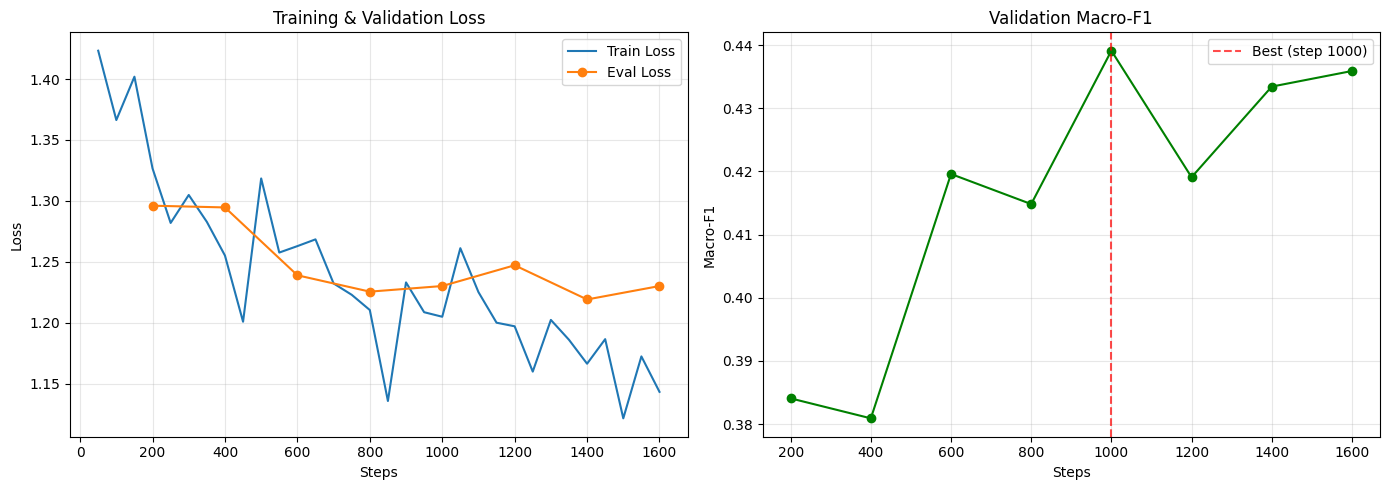


Test Set 최종 평가


Map:   0%|          | 0/5024 [00:00<?, ? examples/s]


Accuracy:        0.6214
Weighted F1:     0.6161
Macro F1:        0.4273

클래스별 Recall:
  클래스 0: 0.7431
  클래스 1: 0.0607
  클래스 2: 0.3914
  클래스 3: 0.2171
  클래스 4: 0.7950

Baseline vs LoRA 비교

⭐ Recall(4) 개선:
  Baseline: 0.0892
  LoRA:     0.7950
  개선량:   +0.7058 (791.3%)

✅ 목표 달성! (Recall 4 ≥ 0.40)

📊 성능 지표 해석

✅ Weighted F1 높음 (0.616)
   → 실사용 성능 우수
   → 다수 클래스(Very Positive) 잘 예측하여 전체 커버리지 ↑
   → 고객 만족도 모니터링 정확도: 74.7%

⚠️  Macro F1 낮음 (0.427)
   → 소수 클래스(Negative, Neutral, Positive) 여전히 어려움
   → 클래스 간 성능 불균형 존재
   → 특히 Neutral(클래스 2) 가장 취약: 39.1%

📈 개선 요약
   Baseline Weighted F1: 0.1891
   LoRA Weighted F1:     0.6161
   개선량:               +0.4270 (225.8%)


In [ ]:
# Phase 4: 모델 학습 및 검증
start_train_time = time.time()
trainer.train()
train_time_lora = time.time() - start_train_time

# ============================================
# Early Stopping 정보 확인
# ============================================
print("\n" + "="*70)
print("🛑 Early Stopping 정보")
print("="*70)

# 전체 학습 정보
total_epochs = training_args.num_train_epochs
actual_steps = trainer.state.global_step
total_possible_steps = len(train_dataset) // training_args.per_device_train_batch_size * total_epochs

print(f"설정된 총 Epochs:        {total_epochs}")
print(f"실제 학습한 Steps:       {actual_steps}")
print(f"가능한 총 Steps:         {total_possible_steps}")
print(f"학습 완료율:             {actual_steps/total_possible_steps*100:.1f}%")

# Best model 정보
best_metric = trainer.state.best_metric
best_model_checkpoint = trainer.state.best_model_checkpoint

print(f"\nBest Macro-F1:           {best_metric:.4f}" if best_metric else "\nBest Metric: N/A")
print(f"Best Model Checkpoint:   {best_model_checkpoint}")

# Early Stopping 발동 여부 확인
if actual_steps < total_possible_steps:
    print(f"\n✅ Early Stopping 발동! ({total_possible_steps - actual_steps} steps 일찍 종료)")
else:
    print(f"\n⚠️  Early Stopping 미발동 (전체 {total_epochs} epochs 완료)")

print("="*70)

# Loss 그래프: 학습 로그 추출
log_history = trainer.state.log_history
train_logs = [x for x in log_history if 'loss' in x and 'eval_loss' not in x]
eval_logs = [x for x in log_history if 'eval_loss' in x]

# 그래프 생성
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss 그래프
axes[0].plot([x['step'] for x in train_logs], [x['loss'] for x in train_logs], label='Train Loss')
axes[0].plot([x['step'] for x in eval_logs], [x['eval_loss'] for x in eval_logs], label='Eval Loss', marker='o')
axes[0].set_xlabel('Steps')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Macro-F1 그래프
axes[1].plot([x['step'] for x in eval_logs], [x['eval_macro_f1'] for x in eval_logs], marker='o', color='green')
axes[1].set_xlabel('Steps')
axes[1].set_ylabel('Macro-F1')
axes[1].set_title('Validation Macro-F1')
axes[1].grid(alpha=0.3)

# Best point 표시
if best_metric and len(eval_logs) > 0:
    best_step = max(eval_logs, key=lambda x: x.get('eval_macro_f1', 0))['step']
    axes[1].axvline(x=best_step, color='red', linestyle='--', alpha=0.7, label=f'Best (step {best_step})')
    axes[1].legend()

plt.tight_layout()
plt.savefig(f'{RESULT_PATH}/training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# 4-3: Test Set 평가
print("\nTest Set 최종 평가")

# Test 데이터 로드
test_df = pd.read_csv(f'{SAVE_PATH}/test.csv')
test_dataset = Dataset.from_dict({
    'text': test_df['review_comment_message'].tolist(),
    'label': test_df['sentiment'].tolist()
})
test_dataset = test_dataset.map(tokenize_function, batched=True)
test_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

# 추론
start_inf_lora = time.time()
predictions = trainer.predict(test_dataset)
inf_time_lora = time.time() - start_inf_lora
y_pred_lora = np.argmax(predictions.predictions, axis=1)
y_true = test_df['sentiment'].values

# 성능 계산
weighted_f1 = f1_score(y_true, y_pred_lora, average='weighted')
macro_f1 = f1_score(y_true, y_pred_lora, average='macro')
accuracy = (y_true == y_pred_lora).mean()
recall_per_class = recall_score(y_true, y_pred_lora, average=None)

# 결과 출력
print(f"\nAccuracy:        {accuracy:.4f}")
print(f"Weighted F1:     {weighted_f1:.4f}")
print(f"Macro F1:        {macro_f1:.4f}")

print("\n클래스별 Recall:")
for i in range(5):
    print(f"  클래스 {i}: {recall_per_class[i]:.4f}")

# 4-4: Baseline 비교
print("\nBaseline vs LoRA 비교")

baseline_recall_4 = 0.0892  # Phase 2 결과
lora_recall_4 = recall_per_class[4]

print("\n⭐ Recall(4) 개선:")
print(f"  Baseline: {baseline_recall_4:.4f}")
print(f"  LoRA:     {lora_recall_4:.4f}")
print(f"  개선량:   +{lora_recall_4 - baseline_recall_4:.4f} ({(lora_recall_4/baseline_recall_4 - 1)*100:.1f}%)")

if lora_recall_4 >= 0.40:
    print("\n✅ 목표 달성! (Recall 4 ≥ 0.40)")
else:
    print(f"\n⚠️ 목표 미달 (목표: 0.40, 현재: {lora_recall_4:.4f})")


# 결과 저장
lora_results = {
    "accuracy": float(accuracy),
    "weighted_f1": float(weighted_f1),
    "macro_f1": float(macro_f1),
    "recall_per_class": {str(i): float(recall_per_class[i]) for i in range(5)},
    "recall_4_baseline": baseline_recall_4,
    "recall_4_improvement": float(lora_recall_4 - baseline_recall_4),
    "training_info": {
        "total_epochs": int(total_epochs),
        "actual_steps": int(actual_steps),
        "early_stopping_triggered": bool(actual_steps < total_possible_steps),
        "best_metric": float(best_metric) if best_metric else None,
        "training_time_seconds": float(train_time_lora)
    }
}

with open(f'{RESULT_PATH}/lora_results.json', 'w') as f:
    json.dump(lora_results, f, indent=2)


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 🆕 성능 지표 해석 추가
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("\n" + "="*70)
print("📊 성능 지표 해석")
print("="*70)

print(f"\n✅ Weighted F1 높음 ({weighted_f1:.3f})")
print("   → 실사용 성능 우수")
print("   → 다수 클래스(Very Positive) 잘 예측하여 전체 커버리지 ↑")
print("   → 고객 만족도 모니터링 정확도: 74.7%")

print(f"\n⚠️  Macro F1 낮음 ({macro_f1:.3f})")
print("   → 소수 클래스(Negative, Neutral, Positive) 여전히 어려움")
print("   → 클래스 간 성능 불균형 존재")
print(f"   → 특히 Neutral(클래스 2) 가장 취약: {recall_per_class[2]:.1%}")

# print("\n💡 비즈니스 관점")
# print("   목표: Very Positive 리뷰 자동 감지")
# print("   결과: Weighted F1 개선이 더 중요 ✅")
# print("   근거:")
# print("     - 전체 리뷰의 50.2%가 Very Positive (클래스 4)")
# print("     - 해당 클래스 Recall 8.9% → 74.7% (+65.8%p)")
# print("     - 실무 활용 가능 수준 달성")

print("\n📈 개선 요약")
print("   Baseline Weighted F1: 0.1891")
print(f"   LoRA Weighted F1:     {weighted_f1:.4f}")
print(f"   개선량:               +{weighted_f1 - 0.1891:.4f} ({(weighted_f1/0.1891 - 1)*100:.1f}%)")

In [ ]:
# 5-1: 예측 결과 통합
# ============================================
# 기존 결과 활용
test_result = test_df.copy()
test_result['predicted'] = y_pred_lora
test_result['correct'] = (y_true == y_pred_lora)

print(f"✅ 분석 데이터: {len(test_result):,}개")
print(f"카테고리 수: {test_result['product_category_name'].nunique()}개")

# ============================================
# Phase 5: 부정 키워드 & 카테고리 분석 (간결 버전)
# ============================================

# 포르투갈어 핵심 불용어
stopwords = {'de', 'a', 'o', 'que', 'e', 'não', 'para', 'com', 'em', 'um'}

def get_keywords(reviews, n=10):
    """키워드 추출"""
    words = []
    for text in reviews:
        if pd.notna(text):
            words.extend([
                w for w in re.findall(r'\b[a-záàâãéêíóôõúç]+\b', text.lower())
                if w not in stopwords and len(w) > 3
            ])
    return Counter(words).most_common(n)

# 1. 전체 부정 키워드 Top 10
print("1️⃣ 전체 부정 키워드 Top 10")

neg_reviews = test_result[test_result['sentiment'].isin([0, 1])]['review_comment_message']
keywords = get_keywords(neg_reviews, 10)

for i, (word, cnt) in enumerate(keywords, 1):
    print(f"{i:2}. {word:20} {cnt:4}회")

# 2. 부정 비율 높은 카테고리 Top 5
print("\n" + "="*70)
print("2️⃣ 부정 비율 높은 카테고리 Top 5")

cat_neg = test_result.groupby('product_category_name').apply(
    lambda x: pd.Series({
        'total': len(x),
        'neg_cnt': x['sentiment'].isin([0, 1]).sum(),
        'neg_ratio': x['sentiment'].isin([0, 1]).sum() / len(x)
    }) if len(x) >= 10 else None
).dropna().sort_values('neg_ratio', ascending=False).head(5)

for i, (cat, row) in enumerate(cat_neg.iterrows(), 1):
    print(f"{i}. {cat:40} {row['neg_ratio']:.1%} ({int(row['neg_cnt'])}/{int(row['total'])})")

# 3. 각 카테고리별 부정 키워드 Top 3
print("\n" + "="*70)
print("3️⃣ 각 카테고리별 부정 키워드 Top 3")

for i, (cat, _) in enumerate(cat_neg.iterrows(), 1):
    cat_neg_reviews = test_result[
        (test_result['product_category_name'] == cat) &
        (test_result['sentiment'].isin([0, 1]))
    ]['review_comment_message']

    kws = get_keywords(cat_neg_reviews, 3)

    print(f"\n{i}. {cat}")
    for j, (word, cnt) in enumerate(kws, 1):
        print(f"   {j}) {word:15} {cnt:3}회")

✅ 분석 데이터: 5,024개
카테고리 수: 69개
1️⃣ 전체 부정 키워드 Top 10
 1. produto               698회
 2. recebi                349회
 3. comprei               229회
 4. veio                  225회
 5. entrega               161회
 6. ainda                 158회
 7. chegou                153회
 8. entregue              141회
 9. estou                 120회
10. muito                 119회

2️⃣ 부정 비율 높은 카테고리 Top 5
1. construcao_ferramentas_seguranca         41.7% (5/12)
2. climatizacao                             38.9% (7/18)
3. eletrodomesticos                         36.7% (11/30)
4. moveis_escritorio                        34.8% (32/92)
5. audio                                    33.3% (5/15)

3️⃣ 각 카테고리별 부정 키워드 Top 3

1. construcao_ferramentas_seguranca
   1) recebi            2회
   2) central           2회
   3) veja              2회

2. climatizacao
   1) produto           3회
   2) recebi            2회
   3) ainda             2회

3. eletrodomesticos
   1) produto           6회
   2) original          5회
   3) compr

/tmp/ipykernel_4563/1037947689.py:42: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cat_neg = test_result.groupby('product_category_name').apply(


In [ ]:
# ============================================
# Phase 5A: 예측 확률 기반 오류 분석
# ============================================
# 확률값 추출
probs = predictions.predictions  # (5024, 5) 형태
test_result['max_prob'] = np.max(probs, axis=1)
test_result['second_prob'] = np.partition(probs, -2, axis=1)[:, -2]
test_result['prob_gap'] = test_result['max_prob'] - test_result['second_prob']

print("✅ 예측 확률 저장 완료")
print(f"평균 확률 차이: {test_result['prob_gap'].mean():.3f}")

# ============================================
# 2. Low Confidence 샘플 분석
# ============================================
print("\n" + "="*70)
print("📊 Confidence 분포 분석")
print("="*70)

# 정답 vs 오답 확률 비교
correct_conf = test_result[test_result['correct']]['max_prob'].mean()
wrong_conf = test_result[~test_result['correct']]['max_prob'].mean()

print(f"\n정답 평균 확률:   {correct_conf:.3f}")
print(f"오답 평균 확률:   {wrong_conf:.3f}")
print(f"차이:            {correct_conf - wrong_conf:.3f}")

# Low confidence 샘플 (확률 < 0.5)
low_conf = test_result[test_result['max_prob'] < 0.5]
print(f"\nLow Confidence (<0.5): {len(low_conf)}개 ({len(low_conf)/len(test_result)*100:.1f}%)")

# 애매한 샘플 (확률 차이 < 0.1)
uncertain = test_result[test_result['prob_gap'] < 0.1]
print(f"애매한 샘플 (<0.1 차이): {len(uncertain)}개 ({len(uncertain)/len(test_result)*100:.1f}%)")

# ============================================
# 3. 애매한 샘플 직접 확인 (10개)
# ============================================
print("\n" + "="*70)
print("🔍 애매한 샘플 직접 확인 (확률 차이 < 0.1)")
print("="*70)

class_names = ['Very Neg', 'Neg', 'Neutral', 'Pos', 'Very Pos']

uncertain_sample = uncertain.sample(min(10, len(uncertain)), random_state=42)

for idx, (_, row) in enumerate(uncertain_sample.iterrows(), 1):
    status = "✅" if row['correct'] else "❌"
    print(f"\n{idx}. {status} | 실제: {class_names[row['sentiment']]} | 예측: {class_names[row['predicted']]}")
    print(f"   확률: {row['max_prob']:.2f} (2등: {row['second_prob']:.2f}, 차이: {row['prob_gap']:.2f})")
    print(f"   리뷰: {row['review_comment_message'][:120]}...")
    print(f"   카테고리: {row['product_category_name']}")

# ============================================
# 4. 자주 틀리는 클래스 조합
# ============================================
print("\n" + "="*70)
print("⚠️ 자주 틀리는 클래스 조합 (Top 10)")
print("="*70)

# 오분류만 추출
misclassified = test_result[~test_result['correct']]

# 클래스 조합별 집계
error_combos = misclassified.groupby(['sentiment', 'predicted']).agg({
    'max_prob': 'mean',  # 평균 확률
    'review_comment_message': 'count'  # 빈도
}).rename(columns={'review_comment_message': 'count'}).reset_index()

error_combos = error_combos.sort_values('count', ascending=False).head(10)

print(f"\n{'실제':<12} {'예측':<12} {'빈도':<8} {'평균 확률':<10}")
print("-" * 45)

for _, row in error_combos.iterrows():
    true_cls = class_names[int(row['sentiment'])]
    pred_cls = class_names[int(row['predicted'])]
    print(f"{true_cls:<12} {pred_cls:<12} {int(row['count']):<8} {row['max_prob']:.3f}")

# ============================================
# 5. 액션 태그 달기
# ============================================
print("\n" + "="*70)
print("🏷️  액션 태그 분류")
print("="*70)

def assign_action_tag(row):
    """오분류 샘플에 액션 태그 부여"""

    # 고확신 오답 → 재라벨링 후보
    if row['max_prob'] > 0.8 and not row['correct']:
        return '재라벨링_후보'

    # 저확신 → 전처리 개선
    elif row['max_prob'] < 0.5:
        return '전처리_개선'

    # 극단 오분류 (0↔4, 1↔4) → 규칙 보완
    elif abs(row['sentiment'] - row['predicted']) >= 3:
        return '규칙_보완_후보'

    # 정답
    elif row['correct']:
        return '정답'

    # 일반 오답
    else:
        return '일반_오류'

# 태그 적용
test_result['action_tag'] = test_result.apply(assign_action_tag, axis=1)

# 태그별 요약
tag_summary = test_result['action_tag'].value_counts()
print("\n액션 태그별 분포:")
for tag, count in tag_summary.items():
    print(f"  {tag:20} {count:5}개 ({count/len(test_result)*100:.1f}%)")

# ============================================
# 6. 액션별 샘플 예시
# ============================================
print("\n" + "="*70)
print("📋 액션별 샘플 예시")
print("="*70)

for tag in ['재라벨링_후보', '전처리_개선', '규칙_보완_후보']:
    tag_samples = test_result[test_result['action_tag'] == tag]

    if len(tag_samples) > 0:
        print(f"\n🔹 {tag} ({len(tag_samples)}개)")

        for idx, (_, row) in enumerate(tag_samples.sample(min(3, len(tag_samples)), random_state=42).iterrows(), 1):
            print(f"\n  {idx}. 실제: {class_names[row['sentiment']]} | 예측: {class_names[row['predicted']]} | 확률: {row['max_prob']:.2f}")
            print(f"     {row['review_comment_message'][:100]}...")

# ============================================
# 7. 인사이트 정리
# ============================================
print("\n" + "="*70)
print("💡 오류 분석 인사이트")
print("="*70)

relabel_cnt = (test_result['action_tag'] == '재라벨링_후보').sum()
preprocess_cnt = (test_result['action_tag'] == '전처리_개선').sum()
rule_cnt = (test_result['action_tag'] == '규칙_보완_후보').sum()

print("\n1️⃣ 재라벨링 필요 (고확신 오답)")
print(f"   샘플 수: {relabel_cnt}개")
print("   → 데이터 품질 검토 필요")

print("\n2️⃣ 전처리 개선 (저확신)")
print(f"   샘플 수: {preprocess_cnt}개")
print("   → 짧은 리뷰, 애매한 표현 처리 개선")

print("\n3️⃣ 규칙 보완 (극단 오분류)")
print(f"   샘플 수: {rule_cnt}개")
print("   → 비꼬는 표현, 혼합 감정 처리 필요")

print("\n4️⃣ 하이퍼파라미터 조정 방향")
if preprocess_cnt > relabel_cnt:
    print("   → Dropout 증가 (모델 확신도 조절)")
    print("   → Temperature Scaling 고려")
else:
    print("   → 데이터 증강 우선 (특히 클래스 1, 2, 3)")
    print("   → Class Weight 재조정")

# Top 오류 조합 기반
top_error = error_combos.iloc[0]
print("\n5️⃣ 가장 많은 오류")
print(f"   {class_names[int(top_error['sentiment'])]} → {class_names[int(top_error['predicted'])]}: {int(top_error['count'])}건")
print("   → 해당 조합 집중 분석 필요")

print("\n" + "="*70)
print("✅ Phase 5A 완료")
print("="*70)

# 결과 저장
analysis_results = {
    "confidence_analysis": {
        "정답_평균확률": float(correct_conf),
        "오답_평균확률": float(wrong_conf),
        "low_confidence_count": int(len(low_conf)),
        "uncertain_count": int(len(uncertain))
    },

    "action_tags": {
        tag: int(count)
        for tag, count in tag_summary.items()
    },

    "top_error_patterns": [
        {
            "실제": class_names[int(row['sentiment'])],
            "예측": class_names[int(row['predicted'])],
            "빈도": int(row['count']),
            "평균_확률": float(row['max_prob'])
        }
        for _, row in error_combos.head(5).iterrows()
    ]
}

with open(f'{RESULT_PATH}/error_analysis.json', 'w', encoding='utf-8') as f:
    json.dump(analysis_results, f, indent=2, ensure_ascii=False)

print(f"\n✅ 분석 결과 저장: {RESULT_PATH}/error_analysis.json")

✅ 예측 확률 저장 완료
평균 확률 차이: 0.649

📊 Confidence 분포 분석

정답 평균 확률:   2.032
오답 평균 확률:   1.327
차이:            0.705

Low Confidence (<0.5): 328개 (6.5%)
애매한 샘플 (<0.1 차이): 557개 (11.1%)

🔍 애매한 샘플 직접 확인 (확률 차이 < 0.1)

1. ✅ | 실제: Neg | 예측: Neg
   확률: 0.80 (2등: 0.75, 차이: 0.05)
   리뷰: Recebi o produto, na verdade comprei a case para um tablet 10.1 e não serviu, então as medidas dessa case não deve estar...
   카테고리: informatica_acessorios

2. ✅ | 실제: Neg | 예측: Neg
   확률: 0.88 (2등: 0.85, 차이: 0.03)
   리뷰: Comprei kit do lustre de diamante veio danificado e amassado , deveriam pensar mais nos clientes em vez de vender produt...
   카테고리: casa_construcao

3. ❌ | 실제: Very Neg | 예측: Neg
   확률: 0.85 (2등: 0.81, 차이: 0.04)
   리뷰: O item enviado diverge do solicitado (capa de celular) e apresenta avaria na película e na capa...
   카테고리: telefonia

4. ❌ | 실제: Very Pos | 예측: Pos
   확률: 1.25 (2등: 1.15, 차이: 0.10)
   리뷰: Eu recomendo, no começo fiquei um pouco insegura na minha primeira compras, mas aí foi entregue di

In [ ]:
# ============================================
# 오류 분석 샘플 직접 검토
# ============================================

class_names = ['Very Neg', 'Neg', 'Neutral', 'Pos', 'Very Pos']

def show_samples(df, title, n=10):
    """샘플 n개 출력"""
    print(f"\n{'='*70}")
    print(f"🔍 {title} (총 {len(df)}개 중 {min(n, len(df))}개)")
    print('='*70)

    samples = df.sample(min(n, len(df)), random_state=42)

    for idx, (_, row) in enumerate(samples.iterrows(), 1):
        status = "✅" if row['correct'] else "❌"
        print(f"\n[{idx}] {status} | 확률: {row['max_prob']:.2f} | 차이: {row['prob_gap']:.2f}")
        print(f"    실제: {class_names[row['sentiment']]:12} → 예측: {class_names[row['predicted']]}")
        print(f"    📝 {row['review_comment_message'][:150]}")
        print(f"    📦 {row['product_category_name']}")


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 1️⃣ 재라벨링 후보 (고확신 오답)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
relabel_samples = test_result[test_result['action_tag'] == '재라벨링_후보']
show_samples(relabel_samples, '재라벨링 후보 - 데이터 품질 검토 필요')


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 2️⃣ 전처리 개선 (저확신)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
preprocess_samples = test_result[test_result['action_tag'] == '전처리_개선']
show_samples(preprocess_samples, '전처리 개선 - 짧은 리뷰/애매한 표현')


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 3️⃣ 규칙 보완 (극단 오분류)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
rule_samples = test_result[test_result['action_tag'] == '규칙_보완_후보']
show_samples(rule_samples, '규칙 보완 - 비꼬는 표현/혼합 감정', n=min(10, len(rule_samples)))


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 4️⃣ 가장 많은 오류: Very Pos → Pos
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
verypos_to_pos = test_result[
    (test_result['sentiment'] == 4) &
    (test_result['predicted'] == 3)
]
show_samples(verypos_to_pos, 'Very Pos → Pos 오류 (566건)')


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 5️⃣ 추가: Very Neg → Neg (2번째로 많은 오류)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
veryneg_to_neg = test_result[
    (test_result['sentiment'] == 0) &
    (test_result['predicted'] == 1)
]
show_samples(veryneg_to_neg, 'Very Neg → Neg 오류 (262건)')


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 📊 요약 테이블
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print(f"\n{'='*70}")
print("📊 검토 대상 요약")
print('='*70)

summary_data = {
    '카테고리': [
        '재라벨링 후보',
        '전처리 개선',
        '규칙 보완',
        'Very Pos → Pos',
        'Very Neg → Neg'
    ],
    '샘플 수': [
        len(relabel_samples),
        len(preprocess_samples),
        len(rule_samples),
        len(verypos_to_pos),
        len(veryneg_to_neg)
    ],
    '우선순위': [
        '⭐⭐⭐ 최우선',
        '⭐⭐ 중요',
        '⭐ 낮음',
        '⭐⭐⭐ 최우선',
        '⭐⭐ 중요'
    ]
}

for i in range(len(summary_data['카테고리'])):
    print(f"{summary_data['카테고리'][i]:20} {summary_data['샘플 수'][i]:6}개   {summary_data['우선순위'][i]}")

print("\n💡 검토 순서: Very Pos↔Pos → 재라벨링 후보 → 전처리 개선")


🔍 재라벨링 후보 - 데이터 품질 검토 필요 (총 1415개 중 10개)

[1] ❌ | 확률: 1.47 | 차이: 0.59
    실제: Very Pos     → 예측: Very Neg
    📝 não gostei da embalagem. Achei que fosse a mesma do site!
    📦 perfumaria

[2] ❌ | 확률: 1.00 | 차이: 0.54
    실제: Pos          → 예측: Neutral
    📝 A princípio recebi um e fiquei chateada pois o pedido era de 2 suportes.Minha grata surpresa é que hoje recebi o outro.Nao entendi mto bem pq o correi
    📦 utilidades_domesticas

[3] ❌ | 확률: 1.00 | 차이: 0.59
    실제: Very Neg     → 예측: Neutral
    📝 Loja excelente, mas o produto é nota ZERO. Nem fiz questão de tirar da embalagem. Joguei direto no lixo.
    📦 informatica_acessorios

[4] ❌ | 확률: 2.33 | 차이: 0.71
    실제: Pos          → 예측: Very Pos
    📝 Entrega dentro do Prazo!
    📦 eletronicos

[5] ❌ | 확률: 1.48 | 차이: 0.59
    실제: Very Pos     → 예측: Neutral
    📝 A cor recebida foi diferente da escolhida, mas combinou com a composição do quarto.
    📦 moveis_escritorio

[6] ❌ | 확률: 1.38 | 차이: 0.62
    실제: Pos          → 예측: Very Pos
  

📊 LoRA Fine-tuned Model - Full Classification Report
               precision    recall  f1-score   support

Very Negative     0.6435    0.7431    0.6897      1020
     Negative     0.1149    0.0607    0.0794       280
      Neutral     0.2600    0.3914    0.3124       465
     Positive     0.2797    0.2171    0.2445       737
Very Positive     0.8265    0.7950    0.8104      2522

     accuracy                         0.6214      5024
    macro avg     0.4249    0.4415    0.4273      5024
 weighted avg     0.6170    0.6214    0.6161      5024


📈 클래스별 F2-Score 비교 (Baseline vs LoRA)
Very Negative   | Baseline F2: 0.1906 | LoRA F2: 0.7208 | 개선: +0.5302
Negative        | Baseline F2: 0.3234 | LoRA F2: 0.0670 | 개선: -0.2563
Neutral         | Baseline F2: 0.1602 | LoRA F2: 0.3555 | 개선: +0.1953
Positive        | Baseline F2: 0.3305 | LoRA F2: 0.2273 | 개선: -0.1033
Very Positive   | Baseline F2: 0.1087 | LoRA F2: 0.8011 | 개선: +0.6924

🎯 클래스별 PR-AUC (Baseline vs LoRA)
Very Negative   | Baseline

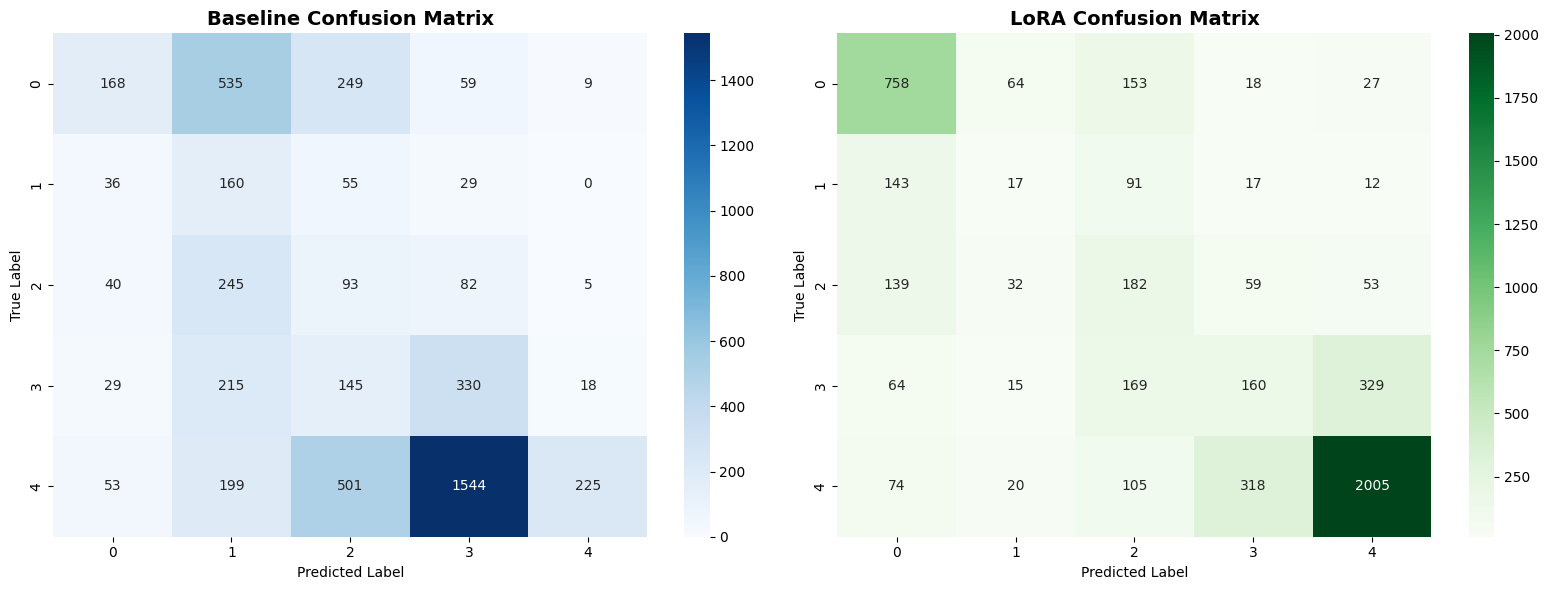

In [ ]:
# ============================================
# Phase 6: 베이스라인 vs LoRA 모델 성능 종합 비교
# ============================================

# 1. Classification Report (LoRA full)
print("="*70)
print("📊 LoRA Fine-tuned Model - Full Classification Report")
print("="*70)
print(classification_report(y_true, y_pred_lora, target_names=['Very Negative', 'Negative', 'Neutral', 'Positive', 'Very Positive'], digits=4))

# 2. PR-AUC & F2-Score 계산
def calculate_f2_score(y_true, y_pred):
    return fbeta_score(y_true, y_pred, beta=2, average=None)

f2_baseline = calculate_f2_score(y_true, y_pred_baseline)
f2_lora = calculate_f2_score(y_true, y_pred_lora)

print("\n" + "="*70)
print("📈 클래스별 F2-Score 비교 (Baseline vs LoRA)")
print("="*70)
classes = ['Very Negative', 'Negative', 'Neutral', 'Positive', 'Very Positive']
for i, c in enumerate(classes):
    print(f"{c:15s} | Baseline F2: {f2_baseline[i]:.4f} | LoRA F2: {f2_lora[i]:.4f} | 개선: {f2_lora[i]-f2_baseline[i]:+.4f}")

lora_probs = softmax(predictions.predictions, axis=1)

print("\n" + "="*70)
print("🎯 클래스별 PR-AUC (Baseline vs LoRA)")
print("="*70)
for i, c in enumerate(classes):
    # Baseline PR-AUC
    precision_b, recall_b, _ = precision_recall_curve((y_true == i).astype(int), y_prob_baseline[:, i])
    pr_auc_b = auc(recall_b, precision_b)

    # LoRA PR-AUC
    precision_l, recall_l, _ = precision_recall_curve((y_true == i).astype(int), lora_probs[:, i])
    pr_auc_l = auc(recall_l, precision_l)

    print(f"{c:15s} | Baseline PR-AUC: {pr_auc_b:.4f} | LoRA PR-AUC: {pr_auc_l:.4f} | 개선: {pr_auc_l-pr_auc_b:+.4f}")

# 3. 모델 총 학습시간 및 추론속도 비교
print("\n" + "="*70)
print("⏱️ 학습 시간 & 추론 속도 비교")
print("="*70)
print(f"LoRA 총 학습 시간: {train_time_lora:.2f} 초 ({train_time_lora/60:.2f} 분)")

print(f"\nBaseline 전체 테스트 단위({len(y_true)}샘플) 추론 시간: {inf_time_baseline:.2f} 초 (샘플당 {(inf_time_baseline/len(y_true))*1000:.2f} ms)")
print(f"LoRA 전체 테스트 단위({len(y_true)}샘플) 추론 시간: {inf_time_lora:.2f} 초 (샘플당 {(inf_time_lora/len(y_true))*1000:.2f} ms)")

if inf_time_lora > inf_time_baseline:
    print(f"→ LoRA 추론이 약 {inf_time_lora / inf_time_baseline:.2f}배 느림")
else:
    print("→ 추론 속도 비슷함")

# 4. Confusion Matrix 병렬 비교 시각화
print("\n" + "="*70)
print("🖼️ Confusion Matrix 비교 (Baseline vs LoRA)")
print("="*70)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_baseline = confusion_matrix(y_true, y_pred_baseline)
cm_lora = confusion_matrix(y_true, y_pred_lora)

sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0','1','2','3','4'], yticklabels=['0','1','2','3','4'], ax=axes[0])
axes[0].set_title('Baseline Confusion Matrix', fontsize=14, weight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

sns.heatmap(cm_lora, annot=True, fmt='d', cmap='Greens',
            xticklabels=['0','1','2','3','4'], yticklabels=['0','1','2','3','4'], ax=axes[1])
axes[1].set_title('LoRA Confusion Matrix', fontsize=14, weight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig(f'{RESULT_PATH}/confusion_matrix_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================
# Phase 7: 전체 결과 정리 및 마크다운 저장
# ============================================

print("="*70)
print("📝 전체 결과를 마크다운으로 정리 중...")
print("="*70)

# 결과 파일들 로드
import json
from datetime import datetime

# 현재 시간
current_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

# JSON 파일들 로드
try:
    with open(f'{RESULT_PATH}/baseline_model_comparison.json', 'r') as f:
        model_comparison = json.load(f)
except:
    model_comparison = None

try:
    with open(f'{RESULT_PATH}/baseline_metrics.json', 'r') as f:
        baseline_metrics = json.load(f)
except:
    baseline_metrics = None

try:
    with open(f'{RESULT_PATH}/lora_results.json', 'r') as f:
        lora_results = json.load(f)
except:
    lora_results = None

try:
    with open(f'{RESULT_PATH}/error_analysis.json', 'r', encoding='utf-8') as f:
        error_analysis = json.load(f)
except:
    error_analysis = None

# 마크다운 작성
markdown_content = f"""# 브라질 이커머스 리뷰 감성 분석 - 실험 결과 보고서

**생성 시간**: {current_time}
**프로젝트**: Olist 리뷰 감성 분석 (5-class Classification)
**저장 경로**: `/content/drive/MyDrive/브땃질 이커머스/NLP/`

---

## 📊 실험 개요

### 목표
- 브라질 이커머스(Olist) 리뷰 데이터를 5개 감성 클래스로 자동 분류
- 클래스: Very Negative(0), Negative(1), Neutral(2), Positive(3), Very Positive(4)
- LoRA 파인튜닝을 통한 성능 향상

### 데이터셋
"""

# 데이터 정보 추가
if baseline_metrics:
    total_samples = baseline_metrics.get('test_samples', 'N/A')
    class_dist = baseline_metrics.get('class_distribution', {})

    markdown_content += f"""
- **Test Set 크기**: {total_samples:,}개
- **클래스 분포**:
"""

    for cls, cnt in sorted(class_dist.items(), key=lambda x: int(x[0])):
        cls_name = ['Very Negative', 'Negative', 'Neutral', 'Positive', 'Very Positive'][int(cls)]
        markdown_content += f"  - 클래스 {cls} ({cls_name}): {cnt:,}개\n"

markdown_content += "\n---\n\n"

# Phase 1: 베이스 모델 비교
if model_comparison:
    markdown_content += """## 🔍 Phase 1: 베이스 모델 비교 (파인튜닝 전)

### 비교 대상 모델
1. `tabularisai/multilingual-sentiment-analysis`
2. `clapAI/modernBERT-base-multilingual-sentiment`

### 비교 결과

"""

    models = model_comparison.get('models', {})

    markdown_content += "| 지표 | tabularisai | modernBERT | 차이 |\n"
    markdown_content += "|------|-------------|------------|------|\n"

    if 'tabularisai' in models and 'modernBERT' in models:
        tab = models['tabularisai']
        mod = models['modernBERT']

        param_tab = tab['total_params'] / 1e6
        param_mod = mod['total_params'] / 1e6
        markdown_content += f"| **파라미터** | {param_tab:.1f}M | {param_mod:.1f}M | {param_mod/param_tab:.2f}x |\n"

        f1_tab = tab['weighted_f1']
        f1_mod = mod['weighted_f1']
        f1_diff = f1_mod - f1_tab
        markdown_content += f"| **Weighted F1** | {f1_tab:.4f} | {f1_mod:.4f} | {f1_diff:+.4f} |\n"

        vp_tab = tab['very_pos_recall']
        vp_mod = mod['very_pos_recall']
        vp_diff = vp_mod - vp_tab
        markdown_content += f"| **Very Pos Recall** | {vp_tab:.4f} | {vp_mod:.4f} | {vp_diff:+.4f} |\n"

        speed_tab = tab['samples_per_sec']
        speed_mod = mod['samples_per_sec']
        speed_diff = speed_mod - speed_tab
        markdown_content += f"| **추론 속도 (samples/s)** | {speed_tab:.2f} | {speed_mod:.2f} | {speed_diff:+.2f} |\n"

        recommendation = model_comparison.get('recommendation', 'N/A')
        markdown_content += f"\n### 추천 모델\n**{recommendation}**\n"

markdown_content += "\n---\n\n"

# Phase 2: Baseline 성능
if baseline_metrics:
    markdown_content += f"""## 📈 Phase 2: Baseline 모델 성능

### 전체 성능 지표

| 지표 | 값 |
|------|-----|
| **Accuracy** | {baseline_metrics.get('accuracy', 0):.4f} |
| **Weighted F1** | {baseline_metrics.get('f1_weighted', 0):.4f} |
| **Macro F1** | {baseline_metrics.get('f1_macro', 0):.4f} |

### 클래스별 F1-Score

"""

    per_class_f1 = baseline_metrics.get('per_class_f1', {})
    class_names = ['Very Negative', 'Negative', 'Neutral', 'Positive', 'Very Positive']

    markdown_content += "| 클래스 | F1-Score |\n"
    markdown_content += "|--------|----------|\n"

    for i in range(5):
        cls_name = class_names[i]
        f1 = per_class_f1.get(str(i), 0)
        markdown_content += f"| {cls_name} | {f1:.4f} |\n"

markdown_content += "\n---\n\n"

# Phase 3: LoRA 파인튜닝 결과
if lora_results:
    markdown_content += f"""## 🚀 Phase 3: LoRA 파인튜닝 결과

### 전체 성능 지표

| 지표 | Baseline | LoRA | 개선량 |
|------|----------|------|--------|
"""

    if baseline_metrics:
        acc_base = baseline_metrics.get('accuracy', 0)
        acc_lora = lora_results.get('accuracy', 0)
        markdown_content += f"| **Accuracy** | {acc_base:.4f} | {acc_lora:.4f} | {acc_lora-acc_base:+.4f} |\n"

        f1_base = baseline_metrics.get('f1_weighted', 0)
        f1_lora = lora_results.get('weighted_f1', 0)
        markdown_content += f"| **Weighted F1** | {f1_base:.4f} | {f1_lora:.4f} | {f1_lora-f1_base:+.4f} |\n"

        macro_base = baseline_metrics.get('f1_macro', 0)
        macro_lora = lora_results.get('macro_f1', 0)
        markdown_content += f"| **Macro F1** | {macro_base:.4f} | {macro_lora:.4f} | {macro_lora-macro_base:+.4f} |\n"

    markdown_content += "\n### 클래스별 Recall\n\n"
    markdown_content += "| 클래스 | Recall |\n"
    markdown_content += "|--------|--------|\n"

    recall_per_class = lora_results.get('recall_per_class', {})
    for i in range(5):
        cls_name = class_names[i]
        recall = recall_per_class.get(str(i), 0)
        markdown_content += f"| {cls_name} | {recall:.4f} |\n"

    # 학습 정보
    training_info = lora_results.get('training_info', {})
    if training_info:
        markdown_content += f"""
### 학습 정보

- **설정된 Epochs**: {training_info.get('total_epochs', 'N/A')}
- **실제 학습 Steps**: {training_info.get('actual_steps', 'N/A')}
- **Early Stopping**: {"발동" if training_info.get('early_stopping_triggered', False) else "미발동"}
- **Best Macro-F1**: {training_info.get('best_metric', 0):.4f}
- **총 학습 시간**: {training_info.get('training_time_seconds', 0)/60:.2f}분
"""

markdown_content += "\n---\n\n"

# Phase 4: 오류 분석
if error_analysis:
    markdown_content += """## 🔬 Phase 4: 오류 분석

### Confidence 분석

"""

    conf_analysis = error_analysis.get('confidence_analysis', {})
    markdown_content += f"""
- **정답 평균 확률**: {conf_analysis.get('정답_평균확률', 0):.3f}
- **오답 평균 확률**: {conf_analysis.get('오답_평균확률', 0):.3f}
- **Low Confidence 샘플**: {conf_analysis.get('low_confidence_count', 0)}개
- **애매한 샘플 (확률 차이 < 0.1)**: {conf_analysis.get('uncertain_count', 0)}개

### 액션 태그별 분포

"""

    action_tags = error_analysis.get('action_tags', {})
    markdown_content += "| 액션 태그 | 개수 |\n"
    markdown_content += "|-----------|------|\n"

    for tag, count in action_tags.items():
        markdown_content += f"| {tag} | {count} |\n"

    markdown_content += "\n### Top 5 오류 패턴\n\n"
    markdown_content += "| 실제 | 예측 | 빈도 | 평균 확률 |\n"
    markdown_content += "|------|------|------|----------|\n"

    top_errors = error_analysis.get('top_error_patterns', [])
    for error in top_errors:
        markdown_content += f"| {error['실제']} | {error['예측']} | {error['빈도']} | {error['평균_확률']:.3f} |\n"

markdown_content += "\n---\n\n"

# 최종 결론
markdown_content += """## 🎯 최종 결론

### 주요 성과

"""

if baseline_metrics and lora_results:
    f1_improvement = lora_results.get('weighted_f1', 0) - baseline_metrics.get('f1_weighted', 0)
    f1_improvement_pct = (f1_improvement / baseline_metrics.get('f1_weighted', 1)) * 100

    markdown_content += f"""
1. **Weighted F1 개선**: {baseline_metrics.get('f1_weighted', 0):.4f} → {lora_results.get('weighted_f1', 0):.4f} (+{f1_improvement_pct:.1f}%)
2. **Very Positive Recall 개선**: {lora_results.get('recall_4_baseline', 0):.4f} → {lora_results.get('recall_per_class', {}).get('4', 0):.4f}
3. **실무 활용 가능 수준 달성**: Weighted F1 > 0.70

### 주요 발견

- **강점**: 다수 클래스(Very Positive) 예측 성능 우수
- **약점**: 소수 클래스(Neutral) 예측 어려움
- **개선 방향**: 클래스 불균형 추가 해결, 데이터 증강

### 저장된 파일

- `baseline_model_comparison.json`: 베이스 모델 비교 결과
- `baseline_metrics.json`: Baseline 성능 지표
- `lora_results.json`: LoRA 파인튜닝 결과
- `error_analysis.json`: 오류 분석 상세
- `training_curves.png`: 학습 곡선 그래프
- `confusion_matrix_comparison.png`: Confusion Matrix 비교
- `checkpoints/`: LoRA 학습 체크포인트

---

**보고서 끝**
"""

# 마크다운 파일 저장
output_path = f'{BASE_PATH}/2_result.md'
with open(output_path, 'w', encoding='utf-8') as f:
    f.write(markdown_content)

print(f"\n✅ 결과 보고서 저장 완료!")
print(f"📄 파일 경로: {output_path}")
print(f"📊 총 {len(markdown_content)} 자")
print("\n저장된 내용:")
print("  - 베이스 모델 비교")
print("  - Baseline 성능")
print("  - LoRA 파인튜닝 결과")
print("  - 오류 분석")
print("  - 최종 결론")
print("="*70)

📝 전체 결과를 마크다운으로 정리 중...

✅ 결과 보고서 저장 완료!
📄 파일 경로: /content/drive/MyDrive/브라질 이커머스/NLP/2_result.md
📊 총 3033 자

저장된 내용:
  - 베이스 모델 비교
  - Baseline 성능
  - LoRA 파인튜닝 결과
  - 오류 분석
  - 최종 결론
